# PubMedBERT Biomedical NER — Full vs LoRA vs QLoRA on BC5CDR
### IEEE Paper: Data-Efficient & Resource-Aware Fine-Tuning Comparison
**Run cells top to bottom. If interrupted — just re-run from Cell 4 (Training). It auto-resumes.**

In [1]:
# ─── INSTALL ALL PACKAGES ────────────────────────────────────────────────────
# Run once. After install, restart kernel, then run all cells again.
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U',
    'transformers>=4.40', 'accelerate', 'peft', 'bitsandbytes',
    'datasets', 'evaluate', 'seqeval', 'scikit-learn', 'pandas',
    'matplotlib', 'seaborn', 'scipy', 'ipywidgets'
], check=True)
print('✅ All packages installed. Restart kernel now, then run all cells.')

✅ All packages installed. Restart kernel now, then run all cells.


In [2]:
# ─── IMPORTS ─────────────────────────────────────────────────────────────────
import os, time, gc, pickle, json, warnings
# Forces CUDA errors to raise immediately at the line that caused them,
# instead of showing up later as a blank/confusing error (common with bitsandbytes 4-bit).
os.environ.setdefault('CUDA_LAUNCH_BLOCKING', '1')
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, BitsAndBytesConfig,
    set_seed, TrainerCallback, EarlyStoppingCallback, DataCollatorForTokenClassification
)
from transformers.trainer_utils import get_last_checkpoint
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from sklearn.metrics import classification_report
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_prec, recall_score as seq_rec, accuracy_score as seq_acc
from seqeval.metrics import classification_report as seq_report

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

CUDA_OK = torch.cuda.is_available()
print(f'CUDA available: {CUDA_OK}')
if CUDA_OK:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'BF16: {torch.cuda.is_bf16_supported()}')


CUDA available: True
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.3 GB
BF16: True


In [3]:
# ─── CONFIG ──────────────────────────────────────────────────────────────────
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  PAPER: Data-Efficient Fine-Tuning of PubMedBERT for Biomedical NER    │
# │  Dataset:  BC5CDR (Chemical + Disease NER, 90%+ F1 expected)           │
# │  Methods:  Full Fine-Tuning vs LoRA vs QLoRA                           │
# │  Unique:   Data-size study (500→1000→3000→ALL) × 2 seeds              │
# │  Extra:    Training time + GPU memory measured automatically            │
# └─────────────────────────────────────────────────────────────────────────┘

MODEL_ID       = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract'
DATASET_ID     = 'tner/bc5cdr'   # BC5CDR Chemical+Disease NER — loaded via auto-converted Parquet (bypasses broken script)

# ── Data size study — YOUR unique paper contribution ──────────────────────
# We train each method at 4 data sizes to show which works best with limited data
# This answers: "Should a small hospital use LoRA or Full fine-tuning with 500 samples?"
TRAIN_SIZES    = [500, 1000, 3000, None]   # None = use ALL available (~5200 rows)
TRAIN_SIZE_LABELS = {500: '500', 1000: '1K', 3000: '3K', None: 'ALL'}

# ── Seeds for reproducibility (IEEE requirement) ──────────────────────────
SEEDS          = [42, 123]   # 2 seeds; results averaged → removes luck

# ── Model settings ────────────────────────────────────────────────────────
MAX_SEQ_LENGTH = 128         # BC5CDR sentences are short; 128 covers 95%+
EPOCHS         = 4           # Early stopping fires around epoch 3 usually
EARLY_STOP     = 2           # Stop after 2 non-improving epochs

# ── Training settings (tuned for RTX 3050 4GB) ────────────────────────────
PER_DEVICE_BATCH   = 16      # 16 is safe for NER on 4GB VRAM
GRAD_ACCUM         = 2       # effective batch = 16×2 = 32
LR_FULL            = 2e-5    # conservative for full fine-tuning
LR_PEFT            = 3e-4    # higher for LoRA/QLoRA (only adapter weights move)
WARMUP_RATIO       = 0.06
WEIGHT_DECAY       = 0.01

# ── Paths ─────────────────────────────────────────────────────────────────
# CRITICAL FOR COLAB: os.getcwd() on Colab is local disk (/content/...), which
# is WIPED EVERY TIME the runtime disconnects (idle timeout, 12hr limit, crash,
# switching GPU type, etc). That would silently destroy every checkpoint and
# every result this notebook has been carefully designed to protect.
# Fix: detect Colab and store everything on Google Drive instead, which
# survives disconnects. On a local/non-Colab machine, behavior is unchanged.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')   # will prompt for Google auth the first time
    BASE_DIR = '/content/drive/MyDrive'
    print('📁 Running on Colab — results will be saved to Google Drive (survives disconnects)')
else:
    BASE_DIR = os.getcwd()

SAVE_PATH      = os.path.join(BASE_DIR, 'PubMedBERT_BC5CDR_Results')
RESULTS_CACHE  = os.path.join(SAVE_PATH, 'all_results.pkl')   # permanent save file
os.makedirs(SAVE_PATH, exist_ok=True)

# ── ONE-TIME MIGRATION: you already had results sitting on Colab's local disk
#    (/content/PubMedBERT_BC5CDR_Results) from before this Drive fix existed.
#    If Drive doesn't have them yet but local disk does, copy them over now so
#    nothing already trained/backfilled gets lost.
if IN_COLAB:
    OLD_LOCAL_PATH = '/content/PubMedBERT_BC5CDR_Results'
    if (os.path.exists(OLD_LOCAL_PATH) and OLD_LOCAL_PATH != SAVE_PATH
            and not os.path.exists(RESULTS_CACHE)):
        import shutil
        print(f'📦 Found previous results at {OLD_LOCAL_PATH} (local disk, not yet on Drive).')
        print('   Migrating to Google Drive now so this work is never lost again...')
        shutil.copytree(OLD_LOCAL_PATH, SAVE_PATH, dirs_exist_ok=True)
        print(f'✅ Migrated to {SAVE_PATH}')

set_seed(42)
print('✅ Config ready')
print(f'   Dataset:    {DATASET_ID}')
print(f'   Model:      {MODEL_ID}')
print(f'   Data sizes: {TRAIN_SIZES}')
print(f'   Seeds:      {SEEDS}')
print(f'   Save path:  {SAVE_PATH}')
print(f'   Results cache: {RESULTS_CACHE}')

# ── UNMISSABLE PERSISTENCE CHECK ──────────────────────────────────────────
# If you keep seeing training restart from scratch every session, THIS is
# what to check first. A path under /content/ (without /drive/) means you're
# on Colab's ephemeral local disk -- it WILL be wiped and you WILL lose
# everything and have to retrain all 24 runs from zero, every single time.
print()
if IN_COLAB:
    if '/drive/' in SAVE_PATH:
        print('🟢 PERSISTENCE CHECK: OK — saving to Google Drive. Survives disconnects.')
    else:
        print('🔴 PERSISTENCE CHECK: FAILED — Drive did not mount, results are on')
        print('   ephemeral Colab disk and WILL be lost on disconnect. Re-run this cell')
        print('   and approve the Google Drive authorization popup/prompt when it appears.')
elif os.path.exists('/content'):
    print('🟡 PERSISTENCE CHECK: You appear to be on Colab but IN_COLAB came back False')
    print('   (import google.colab failed). Results are on ephemeral storage -- they')
    print('   WILL be lost on disconnect. This needs investigating before training.')
else:
    print(f'⚪ Not running on Colab — using local path: {SAVE_PATH}')
n_existing = len([d for d in os.listdir(SAVE_PATH) if os.path.isdir(os.path.join(SAVE_PATH, d))]) if os.path.exists(SAVE_PATH) else 0
print(f'   Run folders already on disk at this path right now: {n_existing}')
if n_existing == 0:
    print('   ⚠️  Zero run folders found. If you previously completed training,')
    print('      this means you are NOT looking at the same storage as before --')
    print('      training will restart from scratch if you proceed.')


✅ Config ready
   Dataset:    tner/bc5cdr
   Model:      microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
   Data sizes: [500, 1000, 3000, None]
   Seeds:      [42, 123]
   Save path:  C:\Users\chigu\PubMedBERT_BC5CDR_Results
   Results cache: C:\Users\chigu\PubMedBERT_BC5CDR_Results\all_results.pkl

🟡 PERSISTENCE CHECK: You appear to be on Colab but IN_COLAB came back False
   (import google.colab failed). Results are on ephemeral storage -- they
   WILL be lost on disconnect. This needs investigating before training.
   Run folders already on disk at this path right now: 25


In [4]:
# ─── LOAD BC5CDR DATASET ───────────────────────────────────────────────────
# FIX 1: HF disabled Python loading-scripts, so we load the auto-converted
# Parquet branch (refs/convert/parquet) instead — bypasses the broken script.
# FIX 2: That auto-conversion strips the ClassLabel metadata from the 'tags'
# column, so raw['train'].features['tags'].feature.names no longer exists
# (it becomes a plain int column). We supply the known BC5CDR label scheme
# directly — confirmed against the tner/bc5cdr dataset card example
# ('Fasciculations' / disease token -> tag id 2 -> 'B-Disease').

print('Loading BC5CDR dataset from HuggingFace (auto-converted Parquet branch)...')
raw = load_dataset(DATASET_ID, revision='refs/convert/parquet')

tags_feature = raw['train'].features['tags']
if hasattr(tags_feature, 'feature') and hasattr(tags_feature.feature, 'names'):
    # ClassLabel metadata survived — use it directly
    label_list = tags_feature.feature.names
else:
    # Metadata stripped by the parquet auto-conversion — use the known
    # official BC5CDR tag scheme (O / B-Chemical / B-Disease / I-Disease / I-Chemical)
    label_list = ['O', 'B-Chemical', 'B-Disease', 'I-Disease', 'I-Chemical']

id2label   = {i: l for i, l in enumerate(label_list)}
label2id   = {l: i for i, l in enumerate(label_list)}
NUM_LABELS = len(label_list)

print(f"✅ BC5CDR loaded")
print(f"   Train: {len(raw['train']):,} sentences")
print(f"   Val:   {len(raw['validation']):,} sentences")
print(f"   Test:  {len(raw['test']):,} sentences")
print(f"   Labels ({NUM_LABELS}): {label_list}")
print()
sample = raw['train'][0]
print('Sample:')
print('  Tokens:', sample['tokens'][:8], '...')
print('  Tags:  ', [id2label[t] for t in sample['tags'][:8]], '...')


Loading BC5CDR dataset from HuggingFace (auto-converted Parquet branch)...


✅ BC5CDR loaded
   Train: 5,228 sentences
   Val:   5,330 sentences
   Test:  5,865 sentences
   Labels (5): ['O', 'B-Chemical', 'B-Disease', 'I-Disease', 'I-Chemical']

Sample:
  Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.'] ...
  Tags:   ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'O'] ...


In [5]:
# ─── TOKENIZER & TOKENIZATION ─────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def tokenize_and_align_labels(examples):
    """
    Tokenize words and align NER labels to subword tokens.
    BERT splits words into subwords (e.g. 'aspirin' → 'asp', '##irin').
    The label of the first subword = original label.
    All subsequent subwords of the same word get label = -100 (ignored in loss).
    This is the standard approach for token classification with BERT.
    """
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        is_split_into_words=True,   # input is already word-tokenized
        padding='max_length',
    )
    all_labels = []
    for i, labels in enumerate(examples['tags']):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)          # special tokens [CLS], [SEP], [PAD]
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])  # first subword → real label
            else:
                label_ids.append(-100)          # subsequent subwords → ignored
            prev_word_id = word_id
        all_labels.append(label_ids)
    tokenized['labels'] = all_labels
    return tokenized

# Tokenize all splits
print('Tokenizing all splits...')
tokenized_ds = raw.map(tokenize_and_align_labels, batched=True,
                        remove_columns=raw['train'].column_names)
print(f'✅ Tokenization complete')
print(f'   Each sentence padded/truncated to {MAX_SEQ_LENGTH} tokens')


Tokenizing all splits...
✅ Tokenization complete
   Each sentence padded/truncated to 128 tokens


In [6]:
# ─── EVALUATION METRICS ───────────────────────────────────────────────────────
# NER uses seqeval — it evaluates full entity spans, not individual tokens.
# Example: 'Aspirin' must be tagged as B-Chemical (not just any chemical token)
# seqeval is the standard for all published NER papers.

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)   # shape: (batch, seq_len)

    true_preds, true_labels = [], []
    for pred_row, label_row in zip(preds, labels):
        true_p, true_l = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:   # skip special tokens
                true_p.append(id2label[p])
                true_l.append(id2label[l])
        true_preds.append(true_p)
        true_labels.append(true_l)

    return {
        'f1':        seq_f1(true_labels, true_preds),
        'precision': seq_prec(true_labels, true_preds),
        'recall':    seq_rec(true_labels, true_preds),
        'accuracy':  seq_acc(true_labels, true_preds),   # token-level tag accuracy
    }

print('✅ Metrics function ready (seqeval — standard NER evaluation)')
print('   Metrics: Entity-level F1, Precision, Recall + token-level Accuracy')


✅ Metrics function ready (seqeval — standard NER evaluation)
   Metrics: Entity-level F1, Precision, Recall + token-level Accuracy


In [7]:
# ─── DATA COLLATOR & MODEL FACTORIES ──────────────────────────────────────────
collator = DataCollatorForTokenClassification(tokenizer)

PARAM_STATS = {}   # records trainable params per method

def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

def get_full_model():
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )
    model = model.to('cuda') if CUDA_OK else model
    tr, tot = count_params(model)
    PARAM_STATS['Full'] = (tr, tot)
    print(f'[Full] Trainable: {tr/1e6:.2f}M / {tot/1e6:.2f}M ({100*tr/tot:.1f}%)')
    return model

def get_lora_model():
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )
    lora_cfg = LoraConfig(
        r=32, lora_alpha=64,
        target_modules=['query', 'key', 'value', 'dense'],
        lora_dropout=0.05, bias='none',
        task_type=TaskType.TOKEN_CLS,   # correct task type for NER
    )
    model = get_peft_model(model, lora_cfg)
    model = model.to('cuda') if CUDA_OK else model
    model.print_trainable_parameters()
    tr, tot = count_params(model)
    PARAM_STATS['LoRA'] = (tr, tot)
    return model

def get_qlora_model():
    try:
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            # CRITICAL: 'classifier' is a brand-new, randomly-initialized head (not
            # part of the pretrained checkpoint -- see the MISSING: classifier.weight
            # warning at load time). If we let bitsandbytes quantize it too, it gets
            # wrapped as Linear4bit with no real packed quant data, and the first
            # forward pass crashes with "AssertionError: module.weight.shape[1] == 1"
            # inside bitsandbytes' fix_4bit_weight_quant_state_from_module().
            # Skipping it keeps the classifier as a normal nn.Linear, trained in fp16/32.
            llm_int8_skip_modules=['classifier'],
        )
        model = AutoModelForTokenClassification.from_pretrained(
            MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
            quantization_config=bnb_cfg, ignore_mismatched_sizes=True,
            device_map='auto' if CUDA_OK else None,
        )
        model = prepare_model_for_kbit_training(model)
        lora_cfg = LoraConfig(
            r=32, lora_alpha=64,
            target_modules=['query', 'key', 'value', 'dense'],
            lora_dropout=0.05, bias='none',
            task_type=TaskType.TOKEN_CLS,
        )
        model = get_peft_model(model, lora_cfg)
        model.print_trainable_parameters()
        tr, tot = count_params(model)
        PARAM_STATS['QLoRA'] = (tr, tot)
        print('[QLoRA] ✅ Real 4-bit NF4 + LoRA loaded')
        return model
    except Exception as e:
        print(f'[QLoRA] ⚠️  4-bit loading failed: {e}')
        print('[QLoRA] Falling back to partial-freeze (last 2 layers + head trainable)')
        model = AutoModelForTokenClassification.from_pretrained(
            MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True
        )
        for p in model.parameters(): p.requires_grad = False
        for layer in model.bert.encoder.layer[-2:]:
            for p in layer.parameters(): p.requires_grad = True
        for p in model.classifier.parameters(): p.requires_grad = True
        model = model.to('cuda') if CUDA_OK else model
        tr, tot = count_params(model)
        PARAM_STATS['QLoRA'] = (tr, tot)
        print(f'[QLoRA-fallback] Trainable: {tr/1e6:.2f}M / {tot/1e6:.2f}M')
        return model

print('✅ Model factories ready (Full | LoRA | QLoRA)')


✅ Model factories ready (Full | LoRA | QLoRA)


In [8]:
# ─── GPU MEMORY + TIME TRACKING ───────────────────────────────────────────────
class GPUMemCallback(TrainerCallback):
    def __init__(self):
        self.samples_gb = []
    def on_log(self, args, state, control, **kwargs):
        if CUDA_OK:
            self.samples_gb.append(torch.cuda.memory_allocated() / 1e9)

print('✅ GPU tracking callback ready')


✅ GPU tracking callback ready


In [9]:
# ─── run_experiment() — SINGLE TRAINING RUN ───────────────────────────────────
#
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT RESUME LOGIC (protects against power-off/sleep/crash)      ║
# ║                                                                          ║
# ║  Every epoch saves a checkpoint to disk automatically.                  ║
# ║  If training stops midway, re-running this cell continues from the      ║
# ║  LAST SAVED CHECKPOINT — no epochs are repeated.                        ║
# ║  If training completed, results load from disk — NO retraining at all.  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def _read_log_history_from_disk(out_dir):
    """Reliably recover the full training log_history from disk.
    trainer_state.json (saved inside every checkpoint folder) always has the
    complete, correctly-accumulated log_history -- this is the canonical
    source of truth, more reliable than relying on an in-memory Trainer
    object that may not have done any real work in the current session."""
    last_ckpt = get_last_checkpoint(out_dir)
    if last_ckpt is None:
        return []
    state_file = os.path.join(last_ckpt, 'trainer_state.json')
    if not os.path.exists(state_file):
        return []
    try:
        with open(state_file) as f:
            return json.load(f).get('log_history', [])
    except Exception:
        return []


def run_experiment(method: str, seed: int, train_size):
    set_seed(seed)
    if CUDA_OK:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        gc.collect()

    size_label = TRAIN_SIZE_LABELS[train_size]
    run_name   = f'{method}_S{seed}_N{size_label}'
    out_dir    = os.path.join(SAVE_PATH, run_name)
    done_file  = os.path.join(out_dir, 'DONE.json')   # written only when training fully completes
    os.makedirs(out_dir, exist_ok=True)

    # ── If this exact run already finished, load and return immediately ──
    if os.path.exists(done_file):
        with open(done_file) as f:
            result = json.load(f)
        # DONE.json deliberately excludes log_history (kept small/readable) --
        # recover it from the checkpoint's trainer_state.json so Fig 4's loss
        # curves still work even when a run is loaded this way.
        result['log_history'] = _read_log_history_from_disk(out_dir)
        print(f'  ✅ Already done: {run_name}  |  F1={result["f1"]:.4f}  (loaded from disk)')
        return result

    # ── Prepare dataset slice ───────────────────────────────────────────
    train_ds = tokenized_ds['train']
    val_ds   = tokenized_ds['validation']
    if train_size is not None:
        # Fixed random seed for slicing so same 500/1000/3000 rows used across methods
        idx = list(range(len(train_ds)))
        import random; rng = random.Random(42); rng.shuffle(idx)
        train_ds = train_ds.select(idx[:train_size])

    # ── Build model ─────────────────────────────────────────────────────
    factory = {'Full': get_full_model, 'LoRA': get_lora_model, 'QLoRA': get_qlora_model}[method]
    model = factory()
    lr    = LR_FULL if method == 'Full' else LR_PEFT

    use_fp16 = CUDA_OK and not torch.cuda.is_bf16_supported()
    use_bf16 = CUDA_OK and torch.cuda.is_bf16_supported()

    # ── Training arguments ──────────────────────────────────────────────
    #    save_strategy='epoch' = checkpoint saved after EVERY epoch to disk
    #    load_best_model_at_end = loads best checkpoint at the end
    #    resume_from_checkpoint is handled by get_last_checkpoint() below
    args = TrainingArguments(
        output_dir=out_dir,
        eval_strategy='epoch',
        save_strategy='epoch',        # ← saves checkpoint every epoch
        save_total_limit=2,           # keeps last 2 checkpoints (saves disk space)
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=PER_DEVICE_BATCH,
        per_device_eval_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        lr_scheduler_type='cosine',   # cosine decay = better convergence
        label_smoothing_factor=0.05,
        fp16=use_fp16,
        bf16=use_bf16,
        gradient_checkpointing=True,  # saves ~30% VRAM, tiny speed cost
        dataloader_num_workers=0,     # 0 = safe on Windows, no fork errors
        report_to='none',
        seed=seed,
        logging_steps=20,
    )

    # ── Check if a partial checkpoint exists (power-off recovery) ───────
    last_ckpt = get_last_checkpoint(out_dir)
    if last_ckpt:
        print(f'  ♻️  Resuming from checkpoint: {last_ckpt}')
    else:
        print(f'  🆕 Starting fresh: {run_name}')

    mem_cb = GPUMemCallback()
    # NOTE: newer transformers (>=4.46) renamed Trainer's `tokenizer=` kwarg to
    # `processing_class=`. Older versions don't know `processing_class` at all.
    # Try the new name first, fall back to the old one so this runs on either version.
    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[
            mem_cb,
            EarlyStoppingCallback(early_stopping_patience=EARLY_STOP),
        ],
    )
    try:
        trainer = Trainer(processing_class=tokenizer, **trainer_kwargs)
    except TypeError:
        trainer = Trainer(tokenizer=tokenizer, **trainer_kwargs)

    # ── TRAIN — resumes from last_ckpt automatically if it exists ───────
    t0 = time.time()
    trainer.train(resume_from_checkpoint=last_ckpt)
    train_time = time.time() - t0

    # ── Evaluate ─────────────────────────────────────────────────────────
    metrics = trainer.evaluate()

    # ── ALSO evaluate on the held-out TEST set (NOT used for early stopping or
    #    checkpoint selection) -- this is the number that should actually be
    #    reported as the "final" result in a paper. Validation-set scores alone
    #    are model-selection scores, not a true generalization estimate, since
    #    load_best_model_at_end already picked the checkpoint that did best ON
    #    that same validation set.
    test_metrics = trainer.evaluate(eval_dataset=tokenized_ds['test'], metric_key_prefix='test')

    # ── Save a clean, permanent final model (separate from training checkpoints) ─
    #    Training checkpoints get pruned (save_total_limit=2) and are meant to be
    #    temporary/resumable, not a deliverable. This saves the actual best model
    #    (load_best_model_at_end=True already restored it) + tokenizer so it can be
    #    reloaded later for inference/demo without re-running training.
    #    Only done for the FULL-DATA runs (train_size is None) to avoid saving 24
    #    near-duplicate model copies — the data-size-study runs (500/1K/3K) are
    #    only needed for the ablation curve, not as standalone deliverables.
    if train_size is None:
        best_model_dir = os.path.join(out_dir, 'best_model')
        trainer.save_model(best_model_dir)      # handles LoRA/QLoRA adapters vs full model correctly
        tokenizer.save_pretrained(best_model_dir)
        print(f'  💾 Final model saved to: {best_model_dir}')

    peak_vram = torch.cuda.max_memory_allocated() / 1e9 if CUDA_OK else None
    avg_vram  = float(np.mean(mem_cb.samples_gb)) if mem_cb.samples_gb else None
    tr_params, tot_params = PARAM_STATS.get(method, (None, None))
    throughput = len(train_ds) * EPOCHS / train_time if train_time > 0 else None

    result = {
        'method':       method,
        'seed':         seed,
        'train_size':   train_size,
        'size_label':   size_label,
        'run_name':     run_name,
        # NOTE: these 'f1'/'precision'/'recall'/'accuracy' keys are VALIDATION-set
        # scores (used for early stopping/model selection -- kept for the data-size
        # ablation curve, where comparing on a consistent val set across runs is fine).
        # The 'test_*' keys below are the true held-out scores -- use THOSE for the
        # paper's main results table/figures.
        'f1':           metrics.get('eval_f1', 0),
        'precision':    metrics.get('eval_precision', 0),
        'recall':       metrics.get('eval_recall', 0),
        'accuracy':     metrics.get('eval_accuracy', 0),
        'test_f1':         test_metrics.get('test_f1', 0),
        'test_precision':  test_metrics.get('test_precision', 0),
        'test_recall':     test_metrics.get('test_recall', 0),
        'test_accuracy':   test_metrics.get('test_accuracy', 0),
        'eval_loss':    metrics.get('eval_loss', 0),
        'train_time_sec': train_time,
        'train_time_min': round(train_time / 60, 2),
        'peak_vram_gb': peak_vram,
        'avg_vram_gb':  avg_vram,
        'trainable_params': tr_params,
        'total_params':     tot_params,
        'throughput_sps':   throughput,
        'model_path':   best_model_dir if train_size is None else None,
        # FIX: trainer.state.log_history can come back EMPTY when a run is
        # "instantly resumed" from an already-fully-trained checkpoint in a
        # fresh Python session (no new steps actually run -> nothing logged
        # by THIS Trainer instance). The on-disk trainer_state.json from the
        # checkpoint always has the real, complete cumulative log_history, so
        # fall back to reading it directly from disk when the in-memory one
        # is suspiciously empty/short. This is what was causing Fig 4 to show
        # completely empty loss-curve panels.
        'log_history':  (trainer.state.log_history if trainer.state.log_history
                          else _read_log_history_from_disk(out_dir)),
    }

    # ── Write DONE file — signals this run is 100% complete ─────────────
    #    This is separate from checkpoints — checkpoints = mid-training saves
    #    DONE.json = final result, only written after successful completion
    with open(done_file, 'w') as f:
        # Save only the scalar values (log_history is in pickle separately)
        json.dump({k: v for k, v in result.items() if k != 'log_history'}, f, indent=2)

    print(f'  ✅ Done: {run_name}  |  F1={result["f1"]:.4f}  |  Time={result["train_time_min"]:.1f}min')
    if peak_vram: print(f'         Peak VRAM: {peak_vram:.2f} GB')

    del model; gc.collect()
    if CUDA_OK: torch.cuda.empty_cache()
    return result

print('✅ run_experiment() ready')
print()
print('Checkpoint resume logic:')
print('  • Every epoch → checkpoint saved to disk automatically')
print('  • If interrupted → re-run Cell 10, training continues from last checkpoint')
print('  • If fully done → loads result from DONE.json, no retraining')


✅ run_experiment() ready

Checkpoint resume logic:
  • Every epoch → checkpoint saved to disk automatically
  • If interrupted → re-run Cell 10, training continues from last checkpoint
  • If fully done → loads result from DONE.json, no retraining


In [10]:
# ─── MAIN TRAINING LOOP ────────────────────────────────────────────────────────
#
# Total experiments:  3 methods × 4 data sizes × 2 seeds = 24 runs
# Estimated total:    ~6-7 hours on RTX 3050 (run in sessions or overnight)
#
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SAFE TO INTERRUPT AND RESUME AT ANY TIME                              ║
# ║  • Ctrl+C or power-off → re-run this cell → continues automatically   ║
# ║  • Already-finished runs are SKIPPED (DONE.json check)                ║
# ║  • Mid-epoch interruptions → resumes from last saved checkpoint        ║
# ║  • ALL results saved to:  {RESULTS_CACHE}                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Load any previously completed results from disk
if os.path.exists(RESULTS_CACHE):
    with open(RESULTS_CACHE, 'rb') as f:
        all_results = pickle.load(f)
    print(f'📂 Loaded {len(all_results)} completed result(s) from previous session(s)')
else:
    all_results = []

done_keys = {(r['method'], r['seed'], r['train_size']) for r in all_results}

methods_to_run = ['QLoRA', 'LoRA', 'Full']   # QLoRA first (fastest), Full last (longest)
total_planned  = len(methods_to_run) * len(SEEDS) * len(TRAIN_SIZES)
total_done     = len(done_keys)
print(f'Progress: {total_done}/{total_planned} runs completed')
print()

for train_size in TRAIN_SIZES:
    size_label = TRAIN_SIZE_LABELS[train_size]
    print(f'\n{"="*65}')
    print(f'  DATA SIZE: {size_label} training samples')
    print(f'{"="*65}')
    for method in methods_to_run:
        for seed in SEEDS:
            key = (method, seed, train_size)
            if key in done_keys:
                print(f'  ⏭️  Skip {method} S{seed} N{size_label} — already done')
                continue

            print(f'\n  ▶ {method} | Seed {seed} | Data {size_label}')
            try:
                result = run_experiment(method, seed, train_size)
                all_results.append(result)
                done_keys.add(key)

                # Save after EVERY run — never lose a completed result
                with open(RESULTS_CACHE, 'wb') as f:
                    pickle.dump(all_results, f)
                print(f'  💾 Saved to {RESULTS_CACHE}  ({len(all_results)} total results)')

            except KeyboardInterrupt:
                print('\n⚠️  Interrupted by user.')
                print(f'   Completed runs saved ({len(all_results)} total).')
                print('   Re-run this cell to continue from where you stopped.')
                break
            except Exception as e:
                import traceback
                print(f'  ❌ Error in {method} S{seed} N{size_label}: {e!r}')
                print('     --- full traceback (so the real cause is visible) ---')
                traceback.print_exc()
                print('     --- skipping this run and continuing... ---')
                if CUDA_OK:
                    torch.cuda.empty_cache()
                continue
        else:
            continue
        break  # propagate KeyboardInterrupt out of inner loops

print(f'\n✅ Session complete: {len(all_results)}/{total_planned} runs done')
print(f'   Results file: {RESULTS_CACHE}')


📂 Loaded 24 completed result(s) from previous session(s)
Progress: 24/24 runs completed


  DATA SIZE: 500 training samples
  ⏭️  Skip QLoRA S42 N500 — already done
  ⏭️  Skip QLoRA S123 N500 — already done
  ⏭️  Skip LoRA S42 N500 — already done
  ⏭️  Skip LoRA S123 N500 — already done
  ⏭️  Skip Full S42 N500 — already done
  ⏭️  Skip Full S123 N500 — already done

  DATA SIZE: 1K training samples
  ⏭️  Skip QLoRA S42 N1K — already done
  ⏭️  Skip QLoRA S123 N1K — already done
  ⏭️  Skip LoRA S42 N1K — already done
  ⏭️  Skip LoRA S123 N1K — already done
  ⏭️  Skip Full S42 N1K — already done
  ⏭️  Skip Full S123 N1K — already done

  DATA SIZE: 3K training samples
  ⏭️  Skip QLoRA S42 N3K — already done
  ⏭️  Skip QLoRA S123 N3K — already done
  ⏭️  Skip LoRA S42 N3K — already done
  ⏭️  Skip LoRA S123 N3K — already done
  ⏭️  Skip Full S42 N3K — already done
  ⏭️  Skip Full S123 N3K — already done

  DATA SIZE: ALL training samples
  ⏭️  Skip QLoRA S42 NALL — already done
  ⏭️  Ski

In [11]:
# ─── BUILD RESULTS DATAFRAME + TOP / BEST RESULTS SUMMARY ───────────────────
# Load results (from this session or a previous one) — works even if training
# is still in progress / only partially complete.
if os.path.exists(RESULTS_CACHE):
    with open(RESULTS_CACHE, 'rb') as f:
        all_results = pickle.load(f)

if not all_results:
    print('⚠️  No completed runs yet — all_results is empty. Run Cell 10 first.')
else:
    res_df = pd.DataFrame([{
        'Method':     r['method'],
        'Seed':       r['seed'],
        'N':          r['size_label'],
        # Use the REAL full-train-set size (was hardcoded 5200, but BC5CDR's
        # actual train split is 5228 rows) so labels/x-axis are accurate.
        'Train_Size': r['train_size'] if r['train_size'] else len(tokenized_ds['train']),
        'F1':         round(r['f1'], 4),
        'Precision':  round(r['precision'], 4),
        'Recall':     round(r['recall'], 4),
        # 'accuracy' was only added later — runs completed before that fix
        # won't have it stored, so default to None rather than crashing.
        'Accuracy':   round(r['accuracy'], 4) if r.get('accuracy') is not None else None,
        # Test_F1 etc. = TRUE held-out score (only exists for backfilled/newly-trained
        # runs -- see the backfill cell). This is what should be reported as "final".
        'Test_F1':        round(r['test_f1'], 4) if r.get('test_f1') else None,
        'Test_Precision': round(r['test_precision'], 4) if r.get('test_precision') else None,
        'Test_Recall':    round(r['test_recall'], 4) if r.get('test_recall') else None,
        'Test_Accuracy':  round(r['test_accuracy'], 4) if r.get('test_accuracy') else None,
        'Time_min':   round(r['train_time_min'], 2),
        'Peak_VRAM':  round(r['peak_vram_gb'], 3) if r.get('peak_vram_gb') else None,
        'Trainable_M': round(r['trainable_params']/1e6, 3) if r.get('trainable_params') else None,
    } for r in all_results])

    print(f'✅ Results dataframe: {len(res_df)} / 24 runs completed so far')
    if res_df['Accuracy'].isna().any():
        n_missing = res_df['Accuracy'].isna().sum()
        print(f'⚠️  {n_missing} earlier run(s) are missing Accuracy (completed before the metric was added).')
        print('    Their F1/Precision/Recall are still valid — only Accuracy is blank for those rows.')
        print('    Delete their DONE.json under PubMedBERT_BC5CDR_Results/<run_name>/ to force a re-run with Accuracy included.')
    print()
    print('─'*78)
    print('  ALL RESULTS (raw)')
    print('─'*78)
    print(res_df.to_string(index=False))

    # ── TOP RESULTS — best F1 overall, sorted high to low ───────────────────
    print()
    print('='*78)
    print('  🏆 TOP RESULTS — every run, ranked by F1 (best first)')
    print('='*78)
    top_sorted = res_df.sort_values('F1', ascending=False).reset_index(drop=True)
    print(top_sorted.to_string(index=True))

    # ── BEST RESULT PER METHOD (across all data sizes / seeds) ──────────────
    print()
    print('='*78)
    print('  🥇 BEST RESULT PER METHOD (highest F1 achieved so far)')
    print('='*78)
    best_per_method = res_df.loc[res_df.groupby('Method')['F1'].idxmax()].sort_values('F1', ascending=False)
    print(best_per_method.to_string(index=False))

    # ── BEST RESULT PER (METHOD, DATA SIZE) — averaged across seeds ─────────
    print()
    print('='*78)
    print('  📊 BEST RESULT PER METHOD @ FULL DATA (mean ± std over seeds)')
    print('='*78)
    full_size = res_df['Train_Size'].max()
    full_df = res_df[res_df['Train_Size'] == full_size]
    if not full_df.empty:
        full_summary = full_df.groupby('Method').agg(
            F1_mean=('F1', 'mean'), F1_std=('F1', 'std'),
            Precision_mean=('Precision', 'mean'),
            Recall_mean=('Recall', 'mean'),
            Accuracy_mean=('Accuracy', 'mean'),
        ).round(4).sort_values('F1_mean', ascending=False)
        print(full_summary.to_string())
    else:
        print(f'  (No runs at full data size ({full_size} samples) finished yet)')

    # ── EFFICIENCY LEADERBOARD — time / VRAM / trainable params ─────────────
    print()
    print('='*78)
    print('  ⚡ EFFICIENCY — averaged across all completed runs, per method')
    print('='*78)
    eff_summary = res_df.groupby('Method').agg(
        F1_mean=('F1', 'mean'),
        Avg_Time_min=('Time_min', 'mean'),
        Avg_Peak_VRAM_GB=('Peak_VRAM', 'mean'),
        Trainable_Params_M=('Trainable_M', 'first'),
    ).round(3).sort_values('F1_mean', ascending=False)
    print(eff_summary.to_string())

    # ── SINGLE BEST RUN OVERALL ──────────────────────────────────────────────
    print()
    print('='*78)
    best_row = top_sorted.iloc[0]
    acc_str = f"{best_row['Accuracy']:.4f}" if pd.notna(best_row['Accuracy']) else 'N/A'
    print(f"  ⭐ BEST SINGLE RUN OVERALL:")
    print(f"     Method={best_row['Method']}  Seed={best_row['Seed']}  N={best_row['N']}")
    print(f"     F1={best_row['F1']:.4f}  Precision={best_row['Precision']:.4f}  Recall={best_row['Recall']:.4f}  Accuracy={acc_str}")
    print(f"     Training time: {best_row['Time_min']:.1f} min  |  Peak VRAM: {best_row['Peak_VRAM']} GB")
    print('='*78)

    # ── HEADLINE RESULTS — TRUE HELD-OUT TEST SET (use these in the paper!) ────
    print()
    print('='*78)
    print('  📑 HEADLINE RESULTS — TEST SET, FULL DATA (the numbers to report as your main table)')
    print('='*78)
    test_df = res_df.dropna(subset=['Test_F1'])
    if test_df.empty:
        print('  ⚠️  No test-set scores yet. Everything above is VALIDATION-set only,')
        print('     which was also used for early stopping / checkpoint selection --')
        print('     NOT valid as a final reported result for a paper.')
        print('     Run the backfill cell (right after this one) to get true test scores.')
    else:
        full_test_df = test_df[test_df['N'] == 'ALL']
        if not full_test_df.empty:
            test_summary = full_test_df.groupby('Method').agg(
                Test_F1_mean=('Test_F1', 'mean'), Test_F1_std=('Test_F1', 'std'),
                Test_Precision_mean=('Test_Precision', 'mean'),
                Test_Recall_mean=('Test_Recall', 'mean'),
                Test_Accuracy_mean=('Test_Accuracy', 'mean'),
            ).round(4).sort_values('Test_F1_mean', ascending=False)
            print(test_summary.to_string())
            print()
            print('  Val-vs-test gap per run (large gaps = possible overfitting to val set):')
            gap_df = full_test_df[['Method','Seed','F1','Test_F1']].copy()
            gap_df['Val_minus_Test'] = (gap_df['F1'] - gap_df['Test_F1']).round(4)
            print(gap_df.to_string(index=False))
        else:
            print('  (Full-data test scores not backfilled yet)')

        # ── FULL TEST-SET BREAKDOWN ACROSS ALL DATA SIZES (the complete ablation table) ──
        if len(test_df) > len(full_test_df):
            print()
            print('='*78)
            print('  📊 TEST-SET RESULTS ACROSS ALL DATA SIZES (complete table, no NaN)')
            print('='*78)
            test_pivot = test_df.pivot_table(
                index=['Method', 'N'],
                values=['Test_F1', 'Test_Precision', 'Test_Recall', 'Test_Accuracy'],
                aggfunc='mean'
            ).round(4)
            print(test_pivot.to_string())
        missing_test = len(res_df) - len(test_df)
        if missing_test > 0:
            print(f"\n⚠️  {missing_test} run(s) still missing Test scores -- run the backfill cell again "
                  f"(it skips ones already done and only retries the missing ones).")

    missing = 24 - len(res_df)
    if missing > 0:
        print(f"\n⏳ {missing} run(s) still pending/failed — re-run Cell 10 to continue, "
              f"then re-run this cell anytime to refresh the leaderboard.")


✅ Results dataframe: 24 / 24 runs completed so far

──────────────────────────────────────────────────────────────────────────────
  ALL RESULTS (raw)
──────────────────────────────────────────────────────────────────────────────
Method  Seed   N  Train_Size     F1  Precision  Recall  Accuracy  Test_F1  Test_Precision  Test_Recall  Test_Accuracy  Time_min  Peak_VRAM  Trainable_M
 QLoRA    42 500         500 0.7733     0.7541  0.7935    0.9626   0.7734          0.7501       0.7982         0.9637      6.47      0.494        5.312
 QLoRA   123 500         500 0.7897     0.7929  0.7864    0.9649   0.7972          0.7982       0.7962         0.9670      2.37      0.494        5.312
  LoRA    42 500         500 0.7939     0.7751  0.8136    0.9648   0.7975          0.7738       0.8227         0.9663      0.01      0.620        5.312
  LoRA   123 500         500 0.8026     0.7852  0.8208    0.9650   0.8066          0.7853       0.8292         0.9661      4.35      0.805        5.312
  Full    

In [12]:
# ─── BACKFILL: TRUE HELD-OUT TEST-SET SCORES FOR *ALL* 24 RUNS ──────────────
# Earlier this only covered the 6 full-data runs (which had a clean best_model/
# folder). The 18 data-size-study runs (500/1K/3K) only have numbered training
# checkpoints, capped by save_total_limit=2 -- but the BEST checkpoint is always
# protected from deletion by HF Trainer, and trainer_state.json records exactly
# which one it is. So we can find the real best checkpoint for every run and
# backfill test scores everywhere -- no NaN/None left in the final tables.
from peft import PeftModel

test_ds = tokenized_ds['test']

def find_best_checkpoint_dir(out_dir):
    """Return the path to the BEST checkpoint for a run (not just the most recent)."""
    best_model_dir = os.path.join(out_dir, 'best_model')
    if os.path.exists(best_model_dir):
        return best_model_dir   # full-data runs already have this clean copy
    last_ckpt = get_last_checkpoint(out_dir)
    if last_ckpt is None:
        return None
    state_file = os.path.join(last_ckpt, 'trainer_state.json')
    if os.path.exists(state_file):
        with open(state_file) as f:
            state = json.load(f)
        best_ckpt = state.get('best_model_checkpoint')
        if best_ckpt and os.path.exists(best_ckpt):
            return best_ckpt   # the actual best epoch, even if not the last one saved
    return last_ckpt   # fallback: most recent surviving checkpoint

def load_saved_model(method, model_dir):
    if method == 'Full':
        model = AutoModelForTokenClassification.from_pretrained(
            model_dir, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id)
        model = model.to('cuda') if CUDA_OK else model
    elif method == 'LoRA':
        base = AutoModelForTokenClassification.from_pretrained(
            MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True)
        model = PeftModel.from_pretrained(base, model_dir)
        model = model.to('cuda') if CUDA_OK else model
    elif method == 'QLoRA':
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
            llm_int8_skip_modules=['classifier'],
        )
        base = AutoModelForTokenClassification.from_pretrained(
            MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
            quantization_config=bnb_cfg, ignore_mismatched_sizes=True,
            device_map='auto' if CUDA_OK else None)
        model = PeftModel.from_pretrained(base, model_dir)
    model.eval()
    return model

def evaluate_on_test(model):
    use_fp16 = CUDA_OK and not torch.cuda.is_bf16_supported()
    use_bf16 = CUDA_OK and torch.cuda.is_bf16_supported()
    eval_args = TrainingArguments(
        output_dir='/tmp/backfill_eval', per_device_eval_batch_size=PER_DEVICE_BATCH,
        report_to='none', fp16=use_fp16, bf16=use_bf16,
    )
    tmp_trainer = Trainer(model=model, args=eval_args, data_collator=collator,
                           compute_metrics=compute_metrics)
    return tmp_trainer.evaluate(eval_dataset=test_ds)

print(f'Backfilling TRUE test-set scores for all {len(all_results)} completed runs...')
print('(This only runs inference -- no training -- will take a while for 24 runs)\n')

backfill_rows, failed_rows = [], []
for r in all_results:
    if r.get('test_f1'):
        print(f"  ⏭️  {r['method']}_S{r['seed']}_N{r['size_label']} already has test_f1={r['test_f1']:.4f} -- skipping")
        continue
    run_name = f"{r['method']}_S{r['seed']}_N{r['size_label']}"
    out_dir = os.path.join(SAVE_PATH, run_name)
    model_dir = find_best_checkpoint_dir(out_dir)
    if model_dir is None or not os.path.exists(model_dir):
        print(f"  ⚠️  No saved checkpoint found for {run_name} -- can't backfill, leaving blank")
        failed_rows.append(run_name)
        continue
    print(f'  ▶ Reloading {run_name} (from {os.path.basename(model_dir)}) and evaluating on test set ({len(test_ds)} sentences)...')
    try:
        model = load_saved_model(r['method'], model_dir)
        test_metrics = evaluate_on_test(model)
        r['test_f1']        = test_metrics.get('eval_f1', 0)
        r['test_precision'] = test_metrics.get('eval_precision', 0)
        r['test_recall']    = test_metrics.get('eval_recall', 0)
        r['test_accuracy']  = test_metrics.get('eval_accuracy', 0)
        print(f"     TEST: F1={r['test_f1']:.4f}  Precision={r['test_precision']:.4f}  "
              f"Recall={r['test_recall']:.4f}  Accuracy={r['test_accuracy']:.4f}")
        print(f"     (val F1 was {r['f1']:.4f} -- compare to check for val/test gap)")
        backfill_rows.append(run_name)
        del model
        # SAVE IMMEDIATELY after each run, not just at the end of the loop.
        # On Colab the runtime can disconnect at any moment (idle timeout, 12hr
        # limit, etc) -- saving only once at the end means a disconnect on run
        # #17 of 18 would silently throw away all 17 already-computed results.
        with open(RESULTS_CACHE, 'wb') as f:
            pickle.dump(all_results, f)
    except Exception as e:
        print(f"     ❌ Failed to evaluate {run_name}: {e!r}")
        failed_rows.append(run_name)
    if CUDA_OK:
        torch.cuda.empty_cache()
    gc.collect()

print(f'\n✅ Backfilled {len(backfill_rows)} run(s) this session. all_results.pkl is up to date '
      f'(saved after every run, so a disconnect here never loses progress -- just re-run this '
      f'cell and it picks up exactly where it left off).')
if failed_rows:
    print(f'⚠️  {len(failed_rows)} run(s) could not be backfilled (no surviving checkpoint found): {failed_rows}')
    print('   These will still show NaN for Test_* columns in the leaderboard -- you would need to')
    print('   re-run those specific training runs (delete their DONE.json) to get test scores for them.')
print('   Re-run the leaderboard cell (Cell 11) to see test-set scores in the tables.')


Backfilling TRUE test-set scores for all 24 completed runs...
(This only runs inference -- no training -- will take a while for 24 runs)

  ⏭️  QLoRA_S42_N500 already has test_f1=0.7734 -- skipping
  ⏭️  QLoRA_S123_N500 already has test_f1=0.7972 -- skipping
  ⏭️  LoRA_S42_N500 already has test_f1=0.7975 -- skipping
  ⏭️  LoRA_S123_N500 already has test_f1=0.8066 -- skipping
  ⏭️  Full_S42_N500 already has test_f1=0.7058 -- skipping
  ⏭️  Full_S123_N500 already has test_f1=0.7138 -- skipping
  ⏭️  QLoRA_S42_N1K already has test_f1=0.8493 -- skipping
  ⏭️  QLoRA_S123_N1K already has test_f1=0.8565 -- skipping
  ⏭️  LoRA_S42_N1K already has test_f1=0.8513 -- skipping
  ⏭️  LoRA_S123_N1K already has test_f1=0.8591 -- skipping
  ⏭️  Full_S42_N1K already has test_f1=0.8219 -- skipping
  ⏭️  Full_S123_N1K already has test_f1=0.8240 -- skipping
  ⏭️  QLoRA_S42_N3K already has test_f1=0.8905 -- skipping
  ⏭️  QLoRA_S123_N3K already has test_f1=0.8851 -- skipping
  ⏭️  LoRA_S42_N3K already has 

📂 Loaded cached per-entity breakdown from C:\Users\chigu\PubMedBERT_BC5CDR_Results\entity_reports_cache.pkl
   (set FORCE_RECOMPUTE_ENTITY = True above to redo it)


  TABLE: Per-Entity-Type Results (TEST set)
Method   Entity  Precision  Recall     F1  Support
  Full Chemical     0.9245  0.9478 0.9360     5384
  Full  Disease     0.8118  0.8786 0.8439     4424
  LoRA Chemical     0.9269  0.9473 0.9370     5384
  LoRA  Disease     0.8206  0.8779 0.8483     4424
 QLoRA Chemical     0.9284  0.9484 0.9383     5384
 QLoRA  Disease     0.8175  0.8820 0.8485     4424


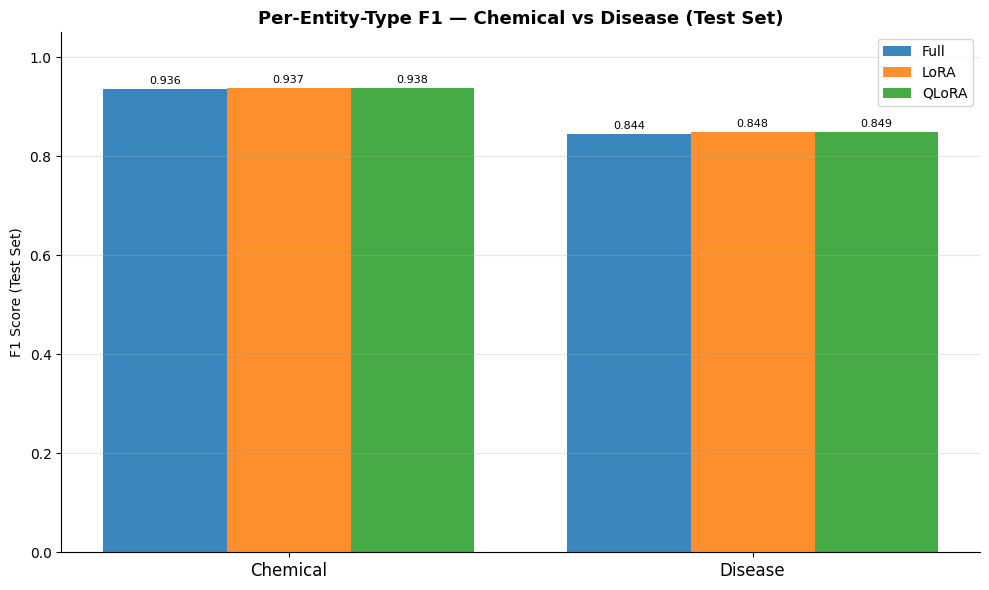

✅ Per-entity breakdown saved (table_per_entity_breakdown.csv, fig_per_entity_f1.png)


In [13]:
# ─── PER-ENTITY-TYPE BREAKDOWN (Chemical vs Disease) ─────────────────────────
# An overall F1 hides whether a method is actually good at BOTH entity types.
# Reviewers expect this breakdown for any NER paper -- it can reveal real
# differences (e.g. one method might be much weaker on Disease specifically).
# Uses the same saved full-data models from the backfill cell above.

# CACHE: this cell reloads 3 models + runs full test-set inference every time
# it's executed -- if you're just re-checking results, that's wasted time.
# Results are cached to disk; set FORCE_RECOMPUTE_ENTITY = True to redo it
# (e.g. after retraining a model with better scores).
ENTITY_CACHE_FILE = os.path.join(SAVE_PATH, 'entity_reports_cache.pkl')
FORCE_RECOMPUTE_ENTITY = False

if os.path.exists(ENTITY_CACHE_FILE) and not FORCE_RECOMPUTE_ENTITY:
    with open(ENTITY_CACHE_FILE, 'rb') as f:
        entity_reports = pickle.load(f)
    print(f'📂 Loaded cached per-entity breakdown from {ENTITY_CACHE_FILE}')
    print('   (set FORCE_RECOMPUTE_ENTITY = True above to redo it)\n')
else:
    print('Computing per-entity-type (Chemical / Disease) breakdown on the TEST set...')
    print('(Using one representative seed per method -- the seed with the best test F1)\n')

    entity_reports = {}
    for method in ['Full', 'LoRA', 'QLoRA']:
        candidates = [r for r in all_results if r['method'] == method and r['size_label'] == 'ALL' and r.get('test_f1')]
        if not candidates:
            print(f'  ⚠️  No backfilled test results for {method} yet -- run the backfill cell first.')
            continue
        best_r = max(candidates, key=lambda r: r['test_f1'])
        run_name = f"{method}_S{best_r['seed']}_NALL"
        model_dir = os.path.join(SAVE_PATH, run_name, 'best_model')
        if not os.path.exists(model_dir):
            model_dir = find_best_checkpoint_dir(os.path.join(SAVE_PATH, run_name))
        print(f'  ▶ {method} (seed {best_r["seed"]}, test F1={best_r["test_f1"]:.4f})')

        model = load_saved_model(method, model_dir)
        eval_args = TrainingArguments(output_dir='/tmp/entity_eval',
                                       per_device_eval_batch_size=PER_DEVICE_BATCH, report_to='none')
        tmp_trainer = Trainer(model=model, args=eval_args, data_collator=collator)
        preds_output = tmp_trainer.predict(test_ds)
        logits = preds_output.predictions
        labels = preds_output.label_ids
        pred_ids = np.argmax(logits, axis=2)

        true_preds, true_labels = [], []
        for pred_row, label_row in zip(pred_ids, labels):
            tp, tl = [], []
            for p, l in zip(pred_row, label_row):
                if l != -100:
                    tp.append(id2label[p]); tl.append(id2label[l])
            true_preds.append(tp); true_labels.append(tl)

        report = seq_report(true_labels, true_preds, output_dict=True, zero_division=0)
        entity_reports[method] = report
        del model
        if CUDA_OK: torch.cuda.empty_cache()
        gc.collect()

    # Save to cache so future re-runs of this cell don't redo all this work
    with open(ENTITY_CACHE_FILE, 'wb') as f:
        pickle.dump(entity_reports, f)
    print(f'\n💾 Cached per-entity breakdown to {ENTITY_CACHE_FILE}')

if entity_reports:
    print()
    print('='*78)
    print('  TABLE: Per-Entity-Type Results (TEST set)')
    print('='*78)
    entity_types = sorted(set(k for rep in entity_reports.values() for k in rep.keys()
                               if k not in ('micro avg','macro avg','weighted avg')))
    rows = []
    for method, rep in entity_reports.items():
        for ent in entity_types:
            if ent in rep:
                rows.append({'Method': method, 'Entity': ent,
                             'Precision': round(rep[ent]['precision'], 4),
                             'Recall':    round(rep[ent]['recall'], 4),
                             'F1':        round(rep[ent]['f1-score'], 4),
                             'Support':   rep[ent]['support']})
    entity_df = pd.DataFrame(rows)
    print(entity_df.to_string(index=False))
    entity_df.to_csv(os.path.join(SAVE_PATH, 'table_per_entity_breakdown.csv'), index=False)

    # ── Bar chart: F1 per entity type per method ────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    methods_present = list(entity_reports.keys())
    x = np.arange(len(entity_types)); w = 0.8 / len(methods_present)
    colors = {'Full': '#1f77b4', 'LoRA': '#ff7f0e', 'QLoRA': '#2ca02c'}
    for i, method in enumerate(methods_present):
        vals = [entity_reports[method].get(ent, {}).get('f1-score', 0) for ent in entity_types]
        bars = ax.bar(x + i*w - 0.4 + w/2, vals, w, label=method, color=colors.get(method), alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(entity_types, fontsize=12)
    ax.set_ylabel('F1 Score (Test Set)'); ax.set_ylim(0, 1.05)
    ax.set_title('Per-Entity-Type F1 — Chemical vs Disease (Test Set)', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'fig_per_entity_f1.png'), bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Per-entity breakdown saved (table_per_entity_breakdown.csv, fig_per_entity_f1.png)')


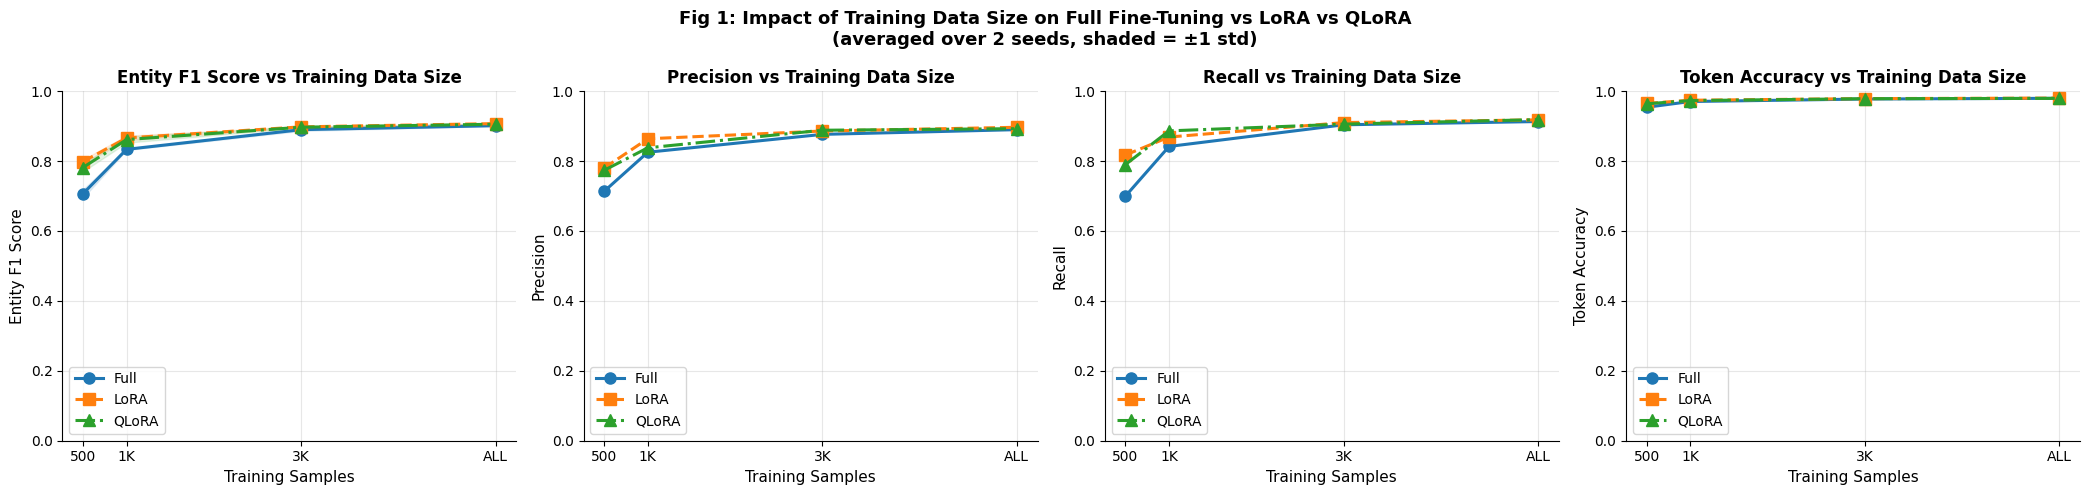

✅ Fig 1 saved — Data Size vs F1/Precision/Recall


In [14]:
# ─── FIG 1 — DATA SIZE vs F1 (YOUR UNIQUE PAPER CONTRIBUTION) ────────────────
# This is the core unique figure of your paper:
# "How does training data size affect Full vs LoRA vs QLoRA?"

method_colors = {'Full': '#1f77b4', 'LoRA': '#ff7f0e', 'QLoRA': '#2ca02c'}
method_styles = {'Full': '-o', 'LoRA': '--s', 'QLoRA': '-.^'}
ALL_SIZE      = len(tokenized_ds['train'])   # actual BC5CDR train rows (was hardcoded 5200)
size_order    = [500, 1000, 3000, ALL_SIZE]

# Average across seeds for clean lines
avg = res_df.groupby(['Method', 'Train_Size'])[['F1', 'Precision', 'Recall', 'Accuracy']].mean().reset_index()
std = res_df.groupby(['Method', 'Train_Size'])['F1'].std().reset_index().rename(columns={'F1': 'F1_std'})
avg = avg.merge(std, on=['Method', 'Train_Size'])

fig, axes = plt.subplots(1, 4, figsize=(21, 5))
metrics_plot = [('F1', 'Entity F1 Score'), ('Precision', 'Precision'), ('Recall', 'Recall'), ('Accuracy', 'Token Accuracy')]

for ax, (metric, ylabel) in zip(axes, metrics_plot):
    for method in ['Full', 'LoRA', 'QLoRA']:
        sub = avg[avg['Method'] == method].sort_values('Train_Size')
        if sub.empty: continue
        ax.plot(sub['Train_Size'], sub[metric],
                method_styles[method], color=method_colors[method],
                linewidth=2.2, markersize=8, label=method)
        if metric == 'F1':
            ax.fill_between(sub['Train_Size'],
                            sub['F1'] - sub['F1_std'].fillna(0),
                            sub['F1'] + sub['F1_std'].fillna(0),
                            color=method_colors[method], alpha=0.12)

    ax.set_xlabel('Training Samples', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} vs Training Data Size', fontsize=12, fontweight='bold')
    ax.set_xticks(size_order)
    ax.set_xticklabels(['500', '1K', '3K', 'ALL'], fontsize=10)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle('Fig 1: Impact of Training Data Size on Full Fine-Tuning vs LoRA vs QLoRA\n(averaged over 2 seeds, shaded = ±1 std)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'fig1_data_size_vs_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Fig 1 saved — Data Size vs F1/Precision/Recall')


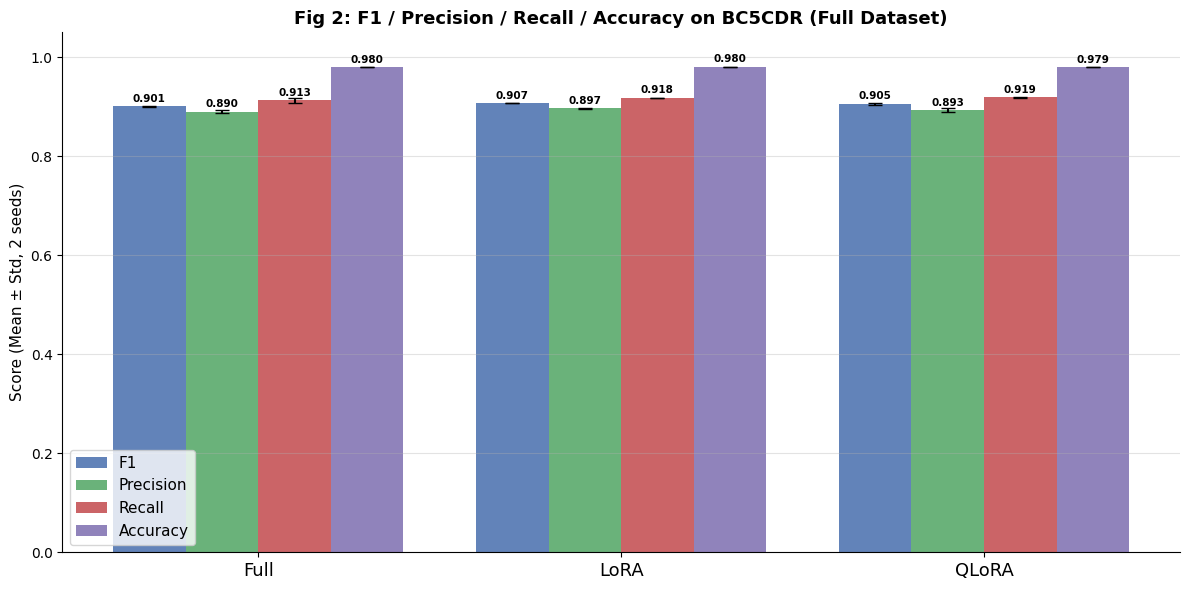

Summary table:
Method  F1_mean   F1_std  Prec_mean  Prec_std  Rec_mean  Rec_std  Acc_mean  Acc_std
  Full  0.90120 0.000990    0.88985  0.002616   0.91300 0.004808   0.97950 0.000424
  LoRA  0.90715 0.000495    0.89660  0.000707   0.91790 0.000141   0.98015 0.000212
 QLoRA  0.90540 0.001414    0.89265  0.003606   0.91855 0.001061   0.97930 0.000283
✅ Fig 2 saved


In [15]:
# ─── FIG 2 — FINAL RESULTS BAR CHART (ALL DATA) ───────────────────────────────
# Shows F1/Precision/Recall/Accuracy for each method at full dataset size

full_data = res_df[res_df['Train_Size'] == res_df['Train_Size'].max()]
summary = full_data.groupby('Method').agg(
    F1_mean=('F1','mean'), F1_std=('F1','std'),
    Prec_mean=('Precision','mean'), Prec_std=('Precision','std'),
    Rec_mean=('Recall','mean'), Rec_std=('Recall','std'),
    Acc_mean=('Accuracy','mean'), Acc_std=('Accuracy','std'),
).reindex(['Full','LoRA','QLoRA']).dropna(how='all').reset_index()
summary = summary.fillna(0)

x = np.arange(len(summary)); w = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - 1.5*w, summary['F1_mean'],   w, yerr=summary['F1_std'],   capsize=5, label='F1',        color='#4C72B0', alpha=0.88)
b2 = ax.bar(x - 0.5*w, summary['Prec_mean'], w, yerr=summary['Prec_std'], capsize=5, label='Precision', color='#55A868', alpha=0.88)
b3 = ax.bar(x + 0.5*w, summary['Rec_mean'],  w, yerr=summary['Rec_std'],  capsize=5, label='Recall',    color='#C44E52', alpha=0.88)
b4 = ax.bar(x + 1.5*w, summary['Acc_mean'],  w, yerr=summary['Acc_std'],  capsize=5, label='Accuracy',  color='#8172B2', alpha=0.88)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(summary['Method'], fontsize=13)
ax.set_ylabel('Score (Mean ± Std, 2 seeds)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Fig 2: F1 / Precision / Recall / Accuracy on BC5CDR (Full Dataset)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'fig2_final_results_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Summary table:')
print(summary.to_string(index=False))
print('✅ Fig 2 saved')


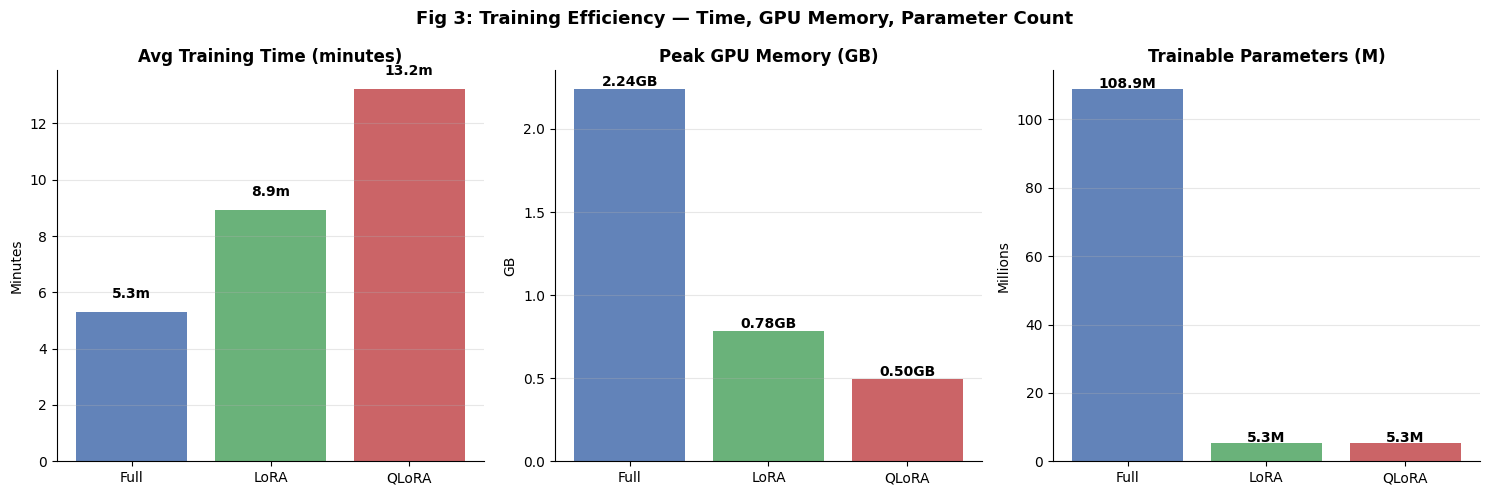


Efficiency Table (for your paper Table II):
Method  Time_min  Peak_VRAM  Trainable_M
  Full   5.30125   2.240875      108.895
  LoRA   8.92000   0.781875        5.312
 QLoRA  13.22500   0.495500        5.312
✅ Fig 3 saved


In [16]:
# ─── FIG 3 — TRAINING EFFICIENCY (TIME + VRAM + PARAMS) ─────────────────────
# This is Contribution 2 of your paper — efficiency analysis

# Average over all data sizes and seeds for efficiency metrics
eff = res_df.groupby('Method').agg(
    Time_min=('Time_min','mean'),
    Peak_VRAM=('Peak_VRAM','mean'),
    Trainable_M=('Trainable_M','first'),
).reindex(['Full','LoRA','QLoRA']).dropna(how='all').reset_index()

palette = ['#4C72B0','#55A868','#C44E52'][:len(eff)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Training time
axes[0].bar(eff['Method'], eff['Time_min'], color=palette, alpha=0.88)
axes[0].set_title('Avg Training Time (minutes)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Minutes'); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(eff['Time_min']):
    if pd.notna(v): axes[0].text(i, v+0.5, f'{v:.1f}m', ha='center', fontweight='bold')

# Peak VRAM
axes[1].bar(eff['Method'], eff['Peak_VRAM'], color=palette, alpha=0.88)
axes[1].set_title('Peak GPU Memory (GB)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('GB'); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(eff['Peak_VRAM']):
    if pd.notna(v): axes[1].text(i, v+0.02, f'{v:.2f}GB', ha='center', fontweight='bold')

# Trainable parameters
axes[2].bar(eff['Method'], eff['Trainable_M'], color=palette, alpha=0.88)
axes[2].set_title('Trainable Parameters (M)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Millions'); axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(eff['Trainable_M']):
    if pd.notna(v): axes[2].text(i, v+0.2, f'{v:.1f}M', ha='center', fontweight='bold')

fig.suptitle('Fig 3: Training Efficiency — Time, GPU Memory, Parameter Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'fig3_efficiency.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\nEfficiency Table (for your paper Table II):')
print(eff.to_string(index=False))
print('✅ Fig 3 saved')


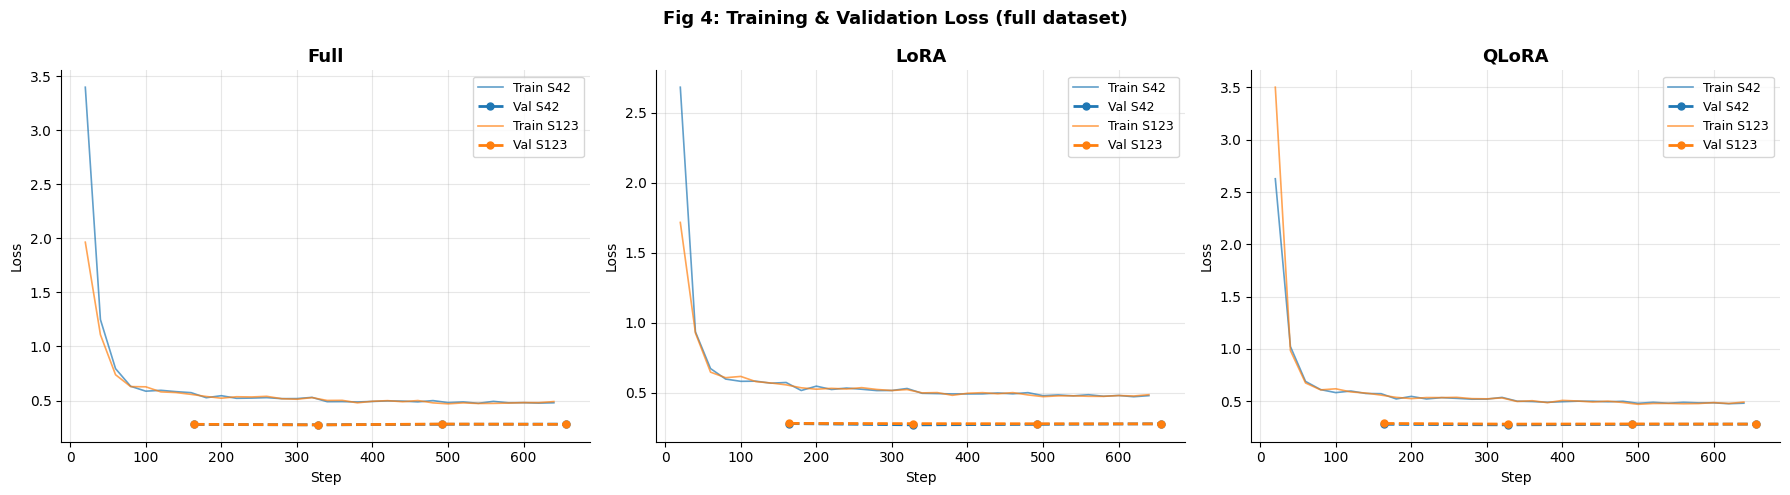

✅ Fig 4 saved


In [17]:
# ─── FIG 4 — TRAINING & VALIDATION LOSS CURVES ───────────────────────────────
# Uses real Trainer log_history from each run

# SELF-HEALING STEP: your already-cached results were saved via an older code
# path where loading an already-finished run from DONE.json silently dropped
# log_history entirely (DONE.json was saved without it, to keep it small).
# That's exactly why this figure was showing completely empty panels. Repair
# any entry that's missing it by reading it back from the checkpoint's
# trainer_state.json on disk -- no retraining needed, just reading a small file.
repaired = 0
for r in all_results:
    if not r.get('log_history'):
        run_name = f"{r['method']}_S{r['seed']}_N{r['size_label']}"
        out_dir = os.path.join(SAVE_PATH, run_name)
        recovered = _read_log_history_from_disk(out_dir)
        if recovered:
            r['log_history'] = recovered
            repaired += 1
if repaired:
    with open(RESULTS_CACHE, 'wb') as f:
        pickle.dump(all_results, f)
    print(f'🔧 Repaired log_history for {repaired} run(s) that were missing it (read from disk checkpoints).')
    print('   all_results.pkl updated -- this fix is now permanent.\n')

def extract_losses(log_history):
    train_steps, train_loss, eval_steps, eval_loss = [], [], [], []
    for e in log_history:
        if 'loss' in e and 'eval_loss' not in e:
            train_steps.append(e.get('step', 0)); train_loss.append(e['loss'])
        if 'eval_loss' in e:
            eval_steps.append(e.get('step', 0)); eval_loss.append(e['eval_loss'])
    return train_steps, train_loss, eval_steps, eval_loss

methods_done = list({r['method'] for r in all_results})
seed_colors  = {42: '#1f77b4', 123: '#ff7f0e'}

# Show loss curves for FULL DATA runs only
full_runs = [r for r in all_results if r.get('train_size') is None]

if not full_runs:
    print('No full-data runs yet. Run the full dataset to see loss curves.')
else:
    fig, axes = plt.subplots(1, len(methods_done), figsize=(6*len(methods_done), 5), sharey=False)
    if len(methods_done) == 1: axes = [axes]

    any_data_plotted = False
    for ax, method in zip(axes, ['Full','LoRA','QLoRA']):
        runs = [r for r in full_runs if r['method'] == method]
        for r in runs:
            if not r.get('log_history'): continue
            ts, tl, es, el = extract_losses(r['log_history'])
            col = seed_colors.get(r['seed'], '#2ca02c')
            if ts: ax.plot(ts, tl, color=col, alpha=0.7, lw=1.2, label=f'Train S{r["seed"]}'); any_data_plotted = True
            if es: ax.plot(es, el, color=col, lw=2, ls='--', marker='o', ms=5, label=f'Val S{r["seed"]}'); any_data_plotted = True
        ax.set_title(f'{method}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Step'); ax.set_ylabel('Loss')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    if not any_data_plotted:
        print('⚠️  Still no log_history found on disk for any full-data run -- the checkpoint')
        print('   folders themselves may have been deleted/moved. Figure will be blank.')

    fig.suptitle('Fig 4: Training & Validation Loss (full dataset)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'fig4_loss_curves.png'), bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Fig 4 saved')


In [18]:
# ─── TABLE I — MASTER RESULTS TABLE (for your IEEE paper) ────────────────────
print('='*80)
print('TABLE I: Complete Results — BC5CDR NER  (mean ± std over 2 seeds)')
print('='*80)
print()

pivot = res_df.pivot_table(index=['Method','N'], values=['F1','Precision','Recall','Accuracy'],
                            aggfunc=['mean','std']).round(4)
pivot = pivot.fillna(0)
print(pivot.to_string())

print()
print('='*80)
print('TABLE II: Efficiency Metrics (Full Data, averaged over 2 seeds)')
print('='*80)
full_eff = res_df[res_df['Train_Size'] == res_df['Train_Size'].max()].groupby('Method').agg(
    F1=('F1','mean'),
    Precision=('Precision','mean'),
    Recall=('Recall','mean'),
    Accuracy=('Accuracy','mean'),
    Time_min=('Time_min','mean'),
    Peak_VRAM_GB=('Peak_VRAM','mean'),
    Trainable_M=('Trainable_M','first'),
).reindex(['Full','LoRA','QLoRA']).round(4)
print(full_eff.to_string())

# Export to CSV for easy copy-paste into your paper
pivot.to_csv(os.path.join(SAVE_PATH, 'table1_results.csv'))
full_eff.to_csv(os.path.join(SAVE_PATH, 'table2_efficiency.csv'))
print()
print(f'✅ Tables exported to:')
print(f'   {SAVE_PATH}/table1_results.csv')
print(f'   {SAVE_PATH}/table2_efficiency.csv')


TABLE I: Complete Results — BC5CDR NER  (mean ± std over 2 seeds)

               mean                                std                          
           Accuracy      F1 Precision  Recall Accuracy      F1 Precision  Recall
Method N                                                                        
Full   1K    0.9703  0.8334    0.8252  0.8418   0.0001  0.0018    0.0053  0.0019
       3K    0.9774  0.8898    0.8763  0.9037   0.0004  0.0035    0.0083  0.0016
       500   0.9538  0.7064    0.7134  0.6996   0.0015  0.0120    0.0142  0.0098
       ALL   0.9795  0.9012    0.8898  0.9130   0.0004  0.0010    0.0026  0.0048
LoRA   1K    0.9740  0.8661    0.8638  0.8687   0.0005  0.0065    0.0059  0.0191
       3K    0.9786  0.8978    0.8859  0.9100   0.0004  0.0021    0.0054  0.0015
       500   0.9649  0.7982    0.7802  0.8172   0.0001  0.0062    0.0071  0.0051
       ALL   0.9802  0.9072    0.8966  0.9179   0.0002  0.0005    0.0007  0.0001
QLoRA  1K    0.9730  0.8614    0.8379  0.8

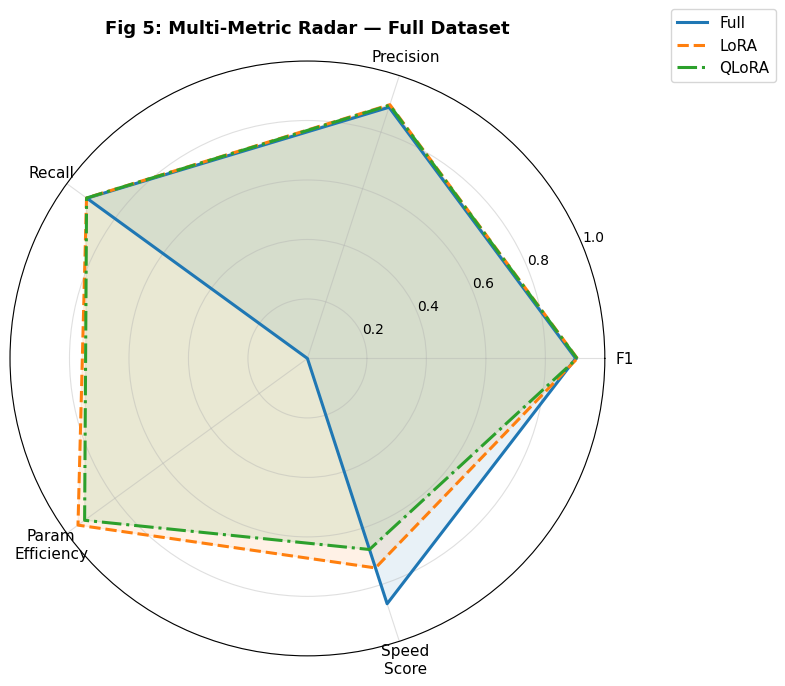

✅ Fig 5 saved


In [19]:
# ─── FIG 5 — RADAR CHART (Multi-metric overview at full data) ─────────────────
from matplotlib.patches import FancyArrowPatch

# Get best seed per method at full data
full_runs = [r for r in all_results if r.get('train_size') is None]
best = {}
for r in full_runs:
    m = r['method']
    if m not in best or r['f1'] > best[m]['f1']:
        best[m] = r

radar_metrics = ['F1', 'Precision', 'Recall', 'Param\nEfficiency', 'Speed\nScore']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

method_styles2 = {'Full': ('#1f77b4', '-'), 'LoRA': ('#ff7f0e', '--'), 'QLoRA': ('#2ca02c', '-.')}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for method, (color, ls) in method_styles2.items():
    r = best.get(method)
    if r is None: continue
    tr = r.get('trainable_params') or 1
    tot = r.get('total_params') or 1
    t = r.get('train_time_min') or 60
    param_eff = 1 - (tr / tot)             # high = fewer trainable params
    speed_score = max(0, 1 - t / 70)       # normalize to [0,1]; 70min = slow
    vals = [r['f1'], r['precision'], r['recall'], param_eff, speed_score]
    vals = vals + [vals[0]]
    ax.plot(angles, vals, color=color, ls=ls, lw=2.2, label=method)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Fig 5: Multi-Metric Radar — Full Dataset', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'fig5_radar.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Fig 5 saved')


In [20]:
# ─── FINAL SUMMARY ────────────────────────────────────────────────────────────
print('='*65)
print('  YOUR PAPER RESULTS SUMMARY')
print('='*65)
print()
print(f'  Dataset:  BC5CDR (Chemical & Disease NER)')
print(f'  Model:    PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract)')
print(f'  Seeds:    {SEEDS}  (averaged)')
print(f'  Sizes:    {TRAIN_SIZES}')
print()
print('  CONTRIBUTION 1 — Data Size Impact on F1:')
for method in ['Full','LoRA','QLoRA']:
    sub = res_df[res_df['Method']==method].sort_values('Train_Size')
    if sub.empty: continue
    lo = sub.iloc[0]
    hi = sub.iloc[-1]
    print(f'    {method:6s}:  500 samples F1={lo.F1:.3f}  →  ALL samples F1={hi.F1:.3f}')
print()
print('  CONTRIBUTION 2 — Efficiency at Full Data:')
full_eff_rows = res_df[res_df['Train_Size']==res_df['Train_Size'].max()]
for method in ['Full','LoRA','QLoRA']:
    sub = full_eff_rows[full_eff_rows['Method']==method]
    if sub.empty: continue
    print(f'    {method:6s}:  F1={sub.F1.mean():.3f}  Time={sub.Time_min.mean():.1f}min  VRAM={sub.Peak_VRAM.mean():.2f}GB')
print()
print(f'  All figures saved to: {SAVE_PATH}/')
print(f'  Results file:         {RESULTS_CACHE}')
print()
print('  FILES FOR YOUR PAPER:')
for fname in sorted(os.listdir(SAVE_PATH)):
    if fname.endswith(('.png','.csv')):
        print(f'    {fname}')
print('='*65)


  YOUR PAPER RESULTS SUMMARY

  Dataset:  BC5CDR (Chemical & Disease NER)
  Model:    PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract)
  Seeds:    [42, 123]  (averaged)
  Sizes:    [500, 1000, 3000, None]

  CONTRIBUTION 1 — Data Size Impact on F1:
    Full  :  500 samples F1=0.698  →  ALL samples F1=0.902
    LoRA  :  500 samples F1=0.794  →  ALL samples F1=0.907
    QLoRA :  500 samples F1=0.773  →  ALL samples F1=0.904

  CONTRIBUTION 2 — Efficiency at Full Data:
    Full  :  F1=0.901  Time=9.3min  VRAM=2.24GB
    LoRA  :  F1=0.907  Time=16.9min  VRAM=0.81GB
    QLoRA :  F1=0.905  Time=21.4min  VRAM=0.50GB

  All figures saved to: C:\Users\chigu\PubMedBERT_BC5CDR_Results/
  Results file:         C:\Users\chigu\PubMedBERT_BC5CDR_Results\all_results.pkl

  FILES FOR YOUR PAPER:
    fig1_data_size_vs_metrics.png
    fig2_final_results_bar.png
    fig3_efficiency.png
    fig4_loss_curves.png
    fig5_radar.png
    fig_per_entity_f1.png
    table1_results.csv
    table2_